In [2]:
import numpy as np 
import matplotlib.pyplot as plt

### 1 - Implementing K-means

The K-means algorithm is a method to automatically cluster similar data points together 
* Concretely, you are given a training data set $\{x^{(1)}, ..., x^{(m)}\}$, and you want to group the data into a few cohesive "clusters"

* K-means is an iterative procesure that
    * Starts by guessing the intial centroids, and then
    * Refines this guess by
      * Repeatedly assigning examples to their closest centroids, and then
      * Recomputing the centroids based on the assignment
* In pseudocode, the K-means algorithm is as follows;

    ``` python
    # Initializze centroids 
    # K is the number of clusters 

    centroids = kMeans_init_centroids(X, K) 

    for iter in range(iterations): 
        #Cluster assignment step: 
        # Assign each data point to the closest centroid 
        # idx[i] corresponds to the index of the centroid 
        # assign to example i 
        idx = find_closest_centroid(X, centroids) 

        # Move centroid step: 
        # Compute means based on centroid assignment 
        centriods = compute_centroids(X, idx, K)
    
    ```

    * The inner-loop of algorithm repeatedly carries out two steps:
      1. Assign each training example $x^(i)$ to its closest centroid, and
      2. Recomputing the mean of each centroid using the points assigned to it
    * The K-means algorithm will always converge to some final set of means for the centroids
    * However, the converged solution may not always be ideal and depends on the initial setting of the centroids
      * Therefore, in practice the K-means algorithm is usually run a few times with different random initializations
      * One way to choose between these different solutions from different random initializations is to choose the one with the lowest cost function value (distortion)

## 1.1 Finding closest centroids 

In [3]:
def find_closest_centroids(X, centroids): 

    K = centroids.shape[0]

    idx = np.zeros(X.shape[0], dtype = int) 

    distance = np.full(X.shape[0], np.inf) 

    for centroid_order in range(K): 
        for index, x in enumerate(X): 
            l2_distance = np.linalg.norm(centroids[centroid_order] - x) 
            
            if l2_distance < distance[index]: 
                distance[index] = l2_distance 
                idx[index] = centroid_order

    return idx

In [4]:
def load_data(): 
    X = np.load("ex7_X.npy") 
    return X

In [5]:
X = load_data()

In [6]:
print("First five elements of X are:\n", X[:5]) 
print("The shape of X is:", X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [7]:
initial_centroids = np.array([[3,3], [6,2], [8,5]])

idx = find_closest_centroids(X, initial_centroids) 

print("First three elements in idx are", idx[:3]) 

First three elements in idx are [0 2 1]


## 1.2 Computing centroid means 

* Specifically, for every centroid $\mu_k$ we set
 $$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$

where 
 * $C_k$ is the set of examples that are assigned to centroid k
 * $|C_k|$ is the number of examples in the set of $C_k$

* Concretely, if two examples say $x^{(3)}$ and $x^{(5)}$ are assigned to centroid $k=2$,
then you should update $\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$.

In [8]:
# def compute_centroids(X, idx, K): 
#     m,n = X.shape 

#     centroids = np.zeros((K, n)) 

#     for centroid_order, centroid in enumerate(centroids): 
#         same_centroid = []
#         for i, assigned_centroid_idx in enumerate(idx): 
#             if assigned_centroid_idx == centroid_order: 
#                 same_centroid.append(X[i])

#         if same_centroid: 
#             same_centroid = np.array(same_centroid) 
#             centroids[centroid_order] = np.mean(same_centroid, axis = 0) 

#     return centroids
import numpy as np

def compute_centroids(X, idx, K):
    """
    Compute the centroids as the mean of all points assigned to each cluster.

    Args:
        X (np.ndarray): Data points, shape (m, n)
        idx (np.ndarray): Cluster assignments for each point, shape (m,)
        K (int): Number of clusters

    Returns:
        np.ndarray: Centroids, shape (K, n)
    """
    m, n = X.shape
    centroids = np.zeros((K, n))

    for k in range(K):
        # Select points assigned to cluster k
        points_in_cluster = X[idx == k]
        if len(points_in_cluster) > 0:
            centroids[k] = np.mean(points_in_cluster, axis=0)
        else:
            # Optionally, keep centroid as zeros or handle empty cluster differently
            pass

    return centroids


In [9]:
K = 3 
centroids = compute_centroids(X, idx, K) 

print("The centroids are:", centroids) 

The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


In [10]:
def run_kMeans(X, initial_centroids, max_iters = 0, plot_progress = False): 
    m,n = X.shape 
    K = initial_centroids.shape[0]
    centroids = initial_centroids 
    previous_centroids = centroids 
    idx = np.zeros(m) 

    for i in range(max_iters): 

        print("K-means iteration %d/%d" % (i, max_iters - 1)) 

        idx = find_closest_centroids(X, centroids) 

        centroids = compute_centroids(X, idx, K) 
    return centroids, idx 

In [11]:
# Load an example dataset
X = load_data()

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])

# Number of iterations
max_iters = 10

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

K-means iteration 0/9
K-means iteration 1/9
K-means iteration 2/9
K-means iteration 3/9
K-means iteration 4/9
K-means iteration 5/9
K-means iteration 6/9
K-means iteration 7/9
K-means iteration 8/9
K-means iteration 9/9


In [12]:
def kMeans_init_centroids(X, K): 

    #randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0]) 

    # take the first K-examples
    centroids = X[randidx[:K]] 

    return centroids 

In [13]:
k = 3
max_iters = 10 

initial_centroids = kMeans_init_centroids(X, K) 

centroids, idx = run_kMeans(X, initial_centroids, max_iters)

K-means iteration 0/9
K-means iteration 1/9
K-means iteration 2/9
K-means iteration 3/9
K-means iteration 4/9
K-means iteration 5/9
K-means iteration 6/9
K-means iteration 7/9
K-means iteration 8/9
K-means iteration 9/9


## 4 - Image Compression with K-means 

In this exercise, you apply K-means to image compression 

* In a straightforward 24-bit color representation of an image, each pixel is represented as three 8-bit unsigned integers (range from 0 to 255) that specify red, green, blue intensity values. This encoding is often referred to as the RGB encoding

* Our image contains thousands of colors, and in this part of the exercise, you will reduce thenumber of colors to 16 colors

* By making this reduction, it is possible to represent the photo in an efficient way

* Specifically, you only need to store the RGB values of the 16 selected colors, and for each pixel in the image you now need to only store the index of the color at that color (where only 4 bits are necessary to represent 16 possibilities) 

In [36]:
original_img = plt.imread('bird_small.png')

(-0.5, 127.5, 127.5, -0.5)

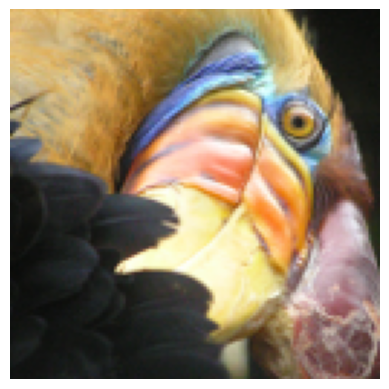

In [17]:
plt.imshow(original_img)
plt.axis('off')

In [18]:
print("shape of original_img is ", original_img.shape)

shape of original_img is  (128, 128, 3)


As you can see, this creates a three-dimensional matrix `original_img` where 
* the first two indices a pixel position, and
* the third index represents red, green, or blue 

In [33]:
# Divide by 255 so that all values are in the range 0 - 1 (not needed for PNG files) 
# original_img = original_img / 255 

# Reshape the image into an m x 3 matrix where m = number of pixels 
# (in this case m = 128 x 128 = 16384) 
# Each row will contain the Red, Green, and Blue pixel values 
# this gives us our dataset matrix X_img that we will use K-means on 

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))
print(X_img[:5])

[[0.85882354 0.7058824  0.40392157]
 [0.9019608  0.7254902  0.45490196]
 [0.8862745  0.7294118  0.43137255]
 [0.8745098  0.7254902  0.4117647 ]
 [0.88235295 0.7019608  0.40392157]]


In [30]:
# Run your K-Means algorithm on this data
# You should try different values of K and max_iters here
K = 16 
max_iters = 10 

# Usin gthe function you have implemented above. 
initial_centroids = kMeans_init_centroids(X_img, K) 

# Run K-Means - this can take a couple of minutes depending on K and max_iters
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters) 

K-means iteration 0/9
K-means iteration 1/9
K-means iteration 2/9
K-means iteration 3/9
K-means iteration 4/9
K-means iteration 5/9
K-means iteration 6/9
K-means iteration 7/9
K-means iteration 8/9
K-means iteration 9/9


In [37]:
print(centroids)

[[0.60330039 0.53267491 0.48718694]
 [0.36965251 0.27870068 0.21341574]
 [0.95712173 0.85359329 0.64283049]
 [0.70402193 0.69905472 0.75439888]
 [0.35269958 0.3835814  0.47124466]
 [0.16775191 0.1681076  0.15910737]
 [0.49928239 0.38068509 0.26835802]
 [0.12141255 0.1307783  0.1216601 ]
 [0.67105013 0.48549652 0.22059549]
 [0.23348066 0.2274204  0.23031908]
 [0.97035336 0.94183534 0.82219672]
 [0.05939587 0.06502381 0.0553355 ]
 [0.09603949 0.10340984 0.09285902]
 [0.07692041 0.08344719 0.07277374]
 [0.84931552 0.71084535 0.47023913]
 [0.82652998 0.60454494 0.31380177]]


In [24]:
print("Shape of idx:", idx.shape) 
print("closest centroid for the first five element:", idx[:5])

Shape of idx: (16384,)
closest centroid for the first five element: [14 14 14 14 14]


## 4.3 Compress the image 

After finding the top K = 16 colors to represent the image, you can now assign each pixel position to its closet centroid using the `find_closest_centroids` function. 

* This allows you to represent the original image using the centroid assignment of each pixel
* Notice that you have significantly reduced the number of bits that re requried to describe the image.
  * The original image required 24 bits for each one of the 128 x 128 pixel locations, resulting the toal size of 128 x 128 x 24 = 393,216 bits
 * The new representation requires some overhead storage in form of a dictionary of 16 colors, each of which require 24 bits, but the image itself then only requires 4 bits per pixel location.
   * The final number of bits used is therefore $16 \times 24 + 128 \times 128 \times 4 = 65,920$ bits, which corresponds to compressing the original image by about a factor of 6.

In [31]:
idx = find_closest_centroids(X_img, centroids) 

X_recovered = centroids[idx, :]

print(X_recovered[:5])

X_recovered = np.reshape(X_recovered, original_img.shape)

[[0.84931552 0.71084535 0.47023913]
 [0.84931552 0.71084535 0.47023913]
 [0.84931552 0.71084535 0.47023913]
 [0.84931552 0.71084535 0.47023913]
 [0.84931552 0.71084535 0.47023913]]


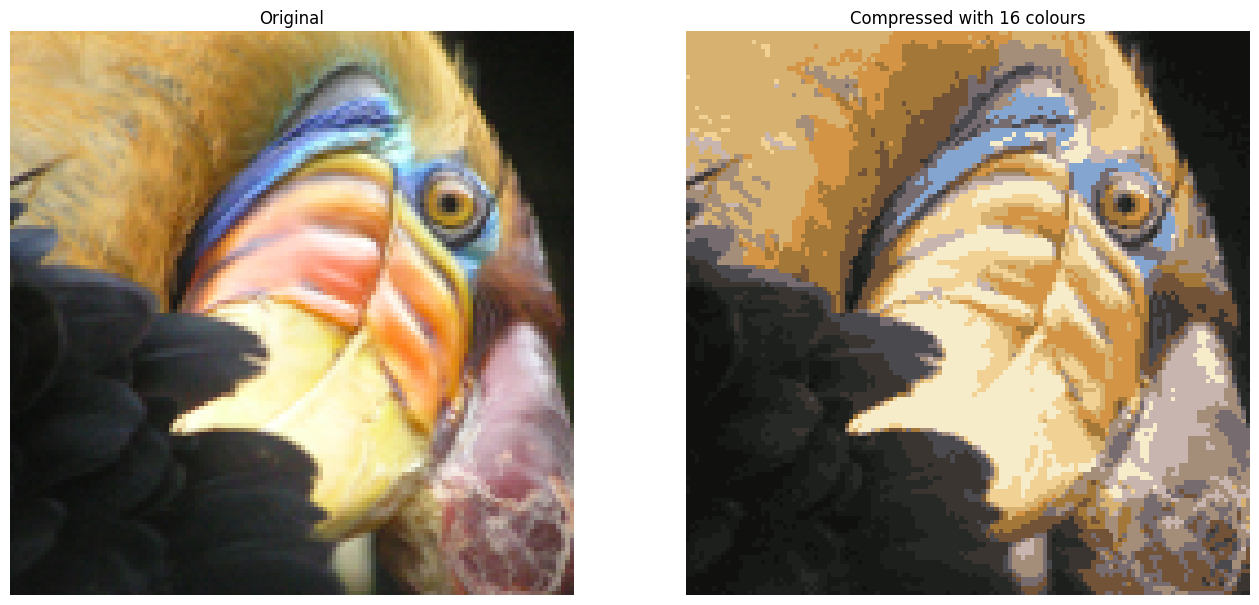

In [26]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()